# Text Image Deblurring using Transfer Learning with Pretrained CNN Models

This notebook trains a deep learning model for text image deblurring using pretrained VGG16/ResNet50 as encoder in an autoencoder architecture.

**Key Features:**
- Transfer learning with VGG16/ResNet50
- Custom decoder for image reconstruction
- PSNR and SSIM metrics
- Model checkpointing and visualization

**Compatible with:** Kaggle, Google Colab, Local GPU

## 1. Setup and Imports

In [2]:
# Check GPU availability
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


In [3]:
# Import required libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# TensorFlow/Keras
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# For metrics
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Configuration

Set up paths and hyperparameters

In [4]:
# Environment Detection and Path Setup
import os

# Detect environment
IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in dir() else False
IS_LOCAL = not (IS_KAGGLE or IS_COLAB)

print(f"Environment: {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'}")

# Set paths based on environment
if IS_KAGGLE:
    # Kaggle paths - your dataset is already added!
    BLUR_DIR = '/kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_data'
    ORIG_DIR = '/kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_OCR_test_data'
    MODEL_SAVE_PATH = '/kaggle/working/saved_models'
    print("✅ Using Kaggle dataset paths")
elif IS_COLAB:
    # Colab paths
    BLUR_DIR = '/content/data/blur'
    ORIG_DIR = '/content/data/orig'
    MODEL_SAVE_PATH = '/content/saved_models'
    print("✅ Using Colab paths")
else:
    # Local paths
    BLUR_DIR = r'R:\AI Image Deblurring\text_deblurring_pretrained\data\blur'
    ORIG_DIR = r'R:\AI Image Deblurring\text_deblurring_pretrained\data\orig'
    MODEL_SAVE_PATH = r'R:\AI Image Deblurring\text_deblurring_pretrained\saved_models'
    print("✅ Using local paths")

print(f"\nDataset paths:")
print(f"  Blur: {BLUR_DIR}")
print(f"  Orig: {ORIG_DIR}")
print(f"  Save: {MODEL_SAVE_PATH}")

Environment: Kaggle
✅ Using Kaggle dataset paths

Dataset paths:
  Blur: /kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_data
  Orig: /kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_OCR_test_data
  Save: /kaggle/working/saved_models


In [5]:
# Verify dataset availability
print("\n" + "="*60)
print("DATASET VERIFICATION")
print("="*60)

if IS_KAGGLE:
    # List available datasets
    input_dir = '/kaggle/input'
    if os.path.exists(input_dir):
        datasets = os.listdir(input_dir)
        print(f"Available datasets in /kaggle/input:")
        for ds in datasets:
            print(f"  - {ds}")
            # Check subdirectories
            ds_path = os.path.join(input_dir, ds)
            if os.path.isdir(ds_path):
                subdirs = os.listdir(ds_path)
                for subdir in subdirs[:5]:  # Show first 5
                    print(f"      └─ {subdir}")
    else:
        print("⚠️  /kaggle/input not found!")

print("\nConfigured paths:")
print(f"  BLUR_DIR: {BLUR_DIR}")
print(f"  ORIG_DIR: {ORIG_DIR}")

# Check if paths exist
blur_exists = os.path.exists(BLUR_DIR)
orig_exists = os.path.exists(ORIG_DIR)

print(f"\nPath check:")
print(f"  Blur directory exists: {'✅' if blur_exists else '❌'}")
print(f"  Orig directory exists: {'✅' if orig_exists else '❌'}")

if blur_exists:
    blur_files = list(Path(BLUR_DIR).glob('**/*'))
    blur_images = [f for f in blur_files if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    print(f"  Files in blur dir: {len(blur_images)}")
    
if orig_exists:
    orig_files = list(Path(ORIG_DIR).glob('**/*'))
    orig_images = [f for f in orig_files if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']]
    print(f"  Files in orig dir: {len(orig_images)}")

print("="*60)


DATASET VERIFICATION
Available datasets in /kaggle/input:
  - text-deblurring-dataset-with-psf-for-ocr
      └─ BMVC_image_quality_test_data
      └─ BMVC_OCR_test_data
      └─ BMVC_image_data

Configured paths:
  BLUR_DIR: /kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_data
  ORIG_DIR: /kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_OCR_test_data

Path check:
  Blur directory exists: ✅
  Orig directory exists: ✅
  Files in blur dir: 200226
  Files in orig dir: 1222


In [6]:
# Configuration
CONFIG = {
    # Paths (automatically set based on environment)
    'BLUR_DIR': BLUR_DIR,
    'ORIG_DIR': ORIG_DIR,
    'MODEL_SAVE_PATH': MODEL_SAVE_PATH,
    
    # Model selection: 'vgg16' or 'resnet50'
    'MODEL_TYPE': 'vgg16',
    
    # Image parameters
    'IMG_HEIGHT': 256,
    'IMG_WIDTH': 256,
    'IMG_CHANNELS': 3,
    
    # Training parameters
    'BATCH_SIZE': 16,
    'EPOCHS': 50,
    'LEARNING_RATE': 0.001,
    'VALIDATION_SPLIT': 0.2,
    
    # Model parameters
    'FREEZE_ENCODER': True,  # Freeze pretrained encoder weights
    
    # For dummy data (if no dataset available)
    'USE_DUMMY_DATA': False,  # Set to True if you want to test with dummy data
    'NUM_DUMMY_SAMPLES': 200
}

# Create save directory
os.makedirs(CONFIG['MODEL_SAVE_PATH'], exist_ok=True)

print("\n" + "="*60)
print("CONFIGURATION SUMMARY")
print("="*60)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print("="*60)


CONFIGURATION SUMMARY
  BLUR_DIR: /kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_data
  ORIG_DIR: /kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_OCR_test_data
  MODEL_SAVE_PATH: /kaggle/working/saved_models
  MODEL_TYPE: vgg16
  IMG_HEIGHT: 256
  IMG_WIDTH: 256
  IMG_CHANNELS: 3
  BATCH_SIZE: 16
  EPOCHS: 50
  LEARNING_RATE: 0.001
  VALIDATION_SPLIT: 0.2
  FREEZE_ENCODER: True
  USE_DUMMY_DATA: False
  NUM_DUMMY_SAMPLES: 200


## 3. Data Loading and Preprocessing

In [7]:
def load_and_preprocess_image(image_path, target_size):
    """
    Load and preprocess a single image.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img


def create_dummy_dataset(blur_dir, orig_dir, num_samples, img_size):
    """
    Create dummy blurred and sharp image pairs for testing.
    """
    os.makedirs(blur_dir, exist_ok=True)
    os.makedirs(orig_dir, exist_ok=True)
    
    print(f"Generating {num_samples} dummy image pairs...")
    
    for i in range(num_samples):
        # Create synthetic image with text-like patterns
        img = np.random.randint(200, 255, (*img_size, 3), dtype=np.uint8)
        
        # Add rectangular regions (simulating text)
        num_rects = np.random.randint(3, 8)
        for _ in range(num_rects):
            x1 = np.random.randint(0, img_size[1] - 50)
            y1 = np.random.randint(0, img_size[0] - 20)
            x2 = x1 + np.random.randint(30, 100)
            y2 = y1 + np.random.randint(10, 30)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 0), -1)
        
        # Save original
        orig_path = os.path.join(orig_dir, f"img_{i:04d}.png")
        cv2.imwrite(orig_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        
        # Create and save blurred version
        blurred = cv2.GaussianBlur(img, (15, 15), 0)
        blur_path = os.path.join(blur_dir, f"img_{i:04d}.png")
        cv2.imwrite(blur_path, cv2.cvtColor(blurred, cv2.COLOR_RGB2BGR))
    
    print(f"Dummy dataset created!")


def load_dataset(blur_dir, orig_dir, img_size):
    """
    Load all image pairs from directories.
    Handles cases where filenames might not match exactly.
    """
    blur_dir = Path(blur_dir)
    orig_dir = Path(orig_dir)
    
    print(f"Loading from:")
    print(f"  Blur: {blur_dir}")
    print(f"  Orig: {orig_dir}")
    
    # Check if directories exist
    if not blur_dir.exists():
        print(f"⚠️  Blur directory does not exist: {blur_dir}")
        return np.array([]), np.array([])
    if not orig_dir.exists():
        print(f"⚠️  Orig directory does not exist: {orig_dir}")
        return np.array([]), np.array([])
    
    # Get image files
    blur_files = sorted([f for f in blur_dir.glob('**/*') 
                        if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']])
    orig_files = sorted([f for f in orig_dir.glob('**/*') 
                        if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']])
    
    print(f"Found {len(blur_files)} blur images")
    print(f"Found {len(orig_files)} orig images")
    
    if len(blur_files) == 0 or len(orig_files) == 0:
        print("⚠️  No images found in one or both directories!")
        return np.array([]), np.array([])
    
    # Try to match images
    # Strategy 1: Match by exact stem
    blur_dict = {f.stem: f for f in blur_files}
    orig_dict = {f.stem: f for f in orig_files}
    
    blur_images = []
    orig_images = []
    matched_count = 0
    
    # First try exact name matching
    for name in blur_dict:
        if name in orig_dict:
            blur_img = load_and_preprocess_image(blur_dict[name], img_size)
            orig_img = load_and_preprocess_image(orig_dict[name], img_size)
            if blur_img is not None and orig_img is not None:
                blur_images.append(blur_img)
                orig_images.append(orig_img)
                matched_count += 1
                if matched_count <= 3:
                    print(f"  ✅ Matched: {name}")
    
    # If no matches, try pairing by index
    if matched_count == 0:
        print("⚠️  No exact name matches found. Pairing images by index...")
        num_pairs = min(len(blur_files), len(orig_files))
        for i in range(num_pairs):
            blur_img = load_and_preprocess_image(blur_files[i], img_size)
            orig_img = load_and_preprocess_image(orig_files[i], img_size)
            if blur_img is not None and orig_img is not None:
                blur_images.append(blur_img)
                orig_images.append(orig_img)
                matched_count += 1
                if matched_count <= 3:
                    print(f"  ✅ Paired: {blur_files[i].name} <-> {orig_files[i].name}")
    
    print(f"\n✅ Successfully loaded {len(blur_images)} image pairs")
    return np.array(blur_images), np.array(orig_images)


# Load or create dataset
img_size = (CONFIG['IMG_HEIGHT'], CONFIG['IMG_WIDTH'])

if CONFIG['USE_DUMMY_DATA']:
    print("Creating dummy dataset...")
    dummy_blur_dir = '/kaggle/working/data/blur'
    dummy_orig_dir = '/kaggle/working/data/orig'
    create_dummy_dataset(dummy_blur_dir, dummy_orig_dir, 
                        CONFIG['NUM_DUMMY_SAMPLES'], img_size)
    X, y = load_dataset(dummy_blur_dir, dummy_orig_dir, img_size)
else:
    print("Loading real dataset...")
    X, y = load_dataset(CONFIG['BLUR_DIR'], CONFIG['ORIG_DIR'], img_size)

# Check if we have data
if len(X) == 0:
    print("\n" + "="*60)
    print("⚠️  ERROR: NO IMAGES LOADED!")
    print("="*60)
    print("\nPossible solutions:")
    print("1. Check if dataset is added in Kaggle (click '+ Add Input')")
    print("2. Verify the dataset paths are correct")
    print("3. Set 'USE_DUMMY_DATA': True to generate test data")
    print("\nCurrent paths:")
    print(f"  BLUR_DIR: {CONFIG['BLUR_DIR']}")
    print(f"  ORIG_DIR: {CONFIG['ORIG_DIR']}")
    print("="*60)
    raise ValueError("No images loaded. Please check dataset paths or use dummy data.")

print(f"\n✅ Dataset loaded successfully!")
print(f"  Blurred images (X): {X.shape}")
print(f"  Original images (y): {y.shape}")

Loading real dataset...
Loading from:
  Blur: /kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_data
  Orig: /kaggle/input/text-deblurring-dataset-with-psf-for-ocr/BMVC_OCR_test_data
Found 200226 blur images
Found 1222 orig images
  ✅ Matched: 0000000_blur
  ✅ Matched: 0000001_blur
  ✅ Matched: 0000002_blur

✅ Successfully loaded 282 image pairs

✅ Dataset loaded successfully!
  Blurred images (X): (282, 256, 256, 3)
  Original images (y): (282, 256, 256, 3)


### Visualize Sample Data

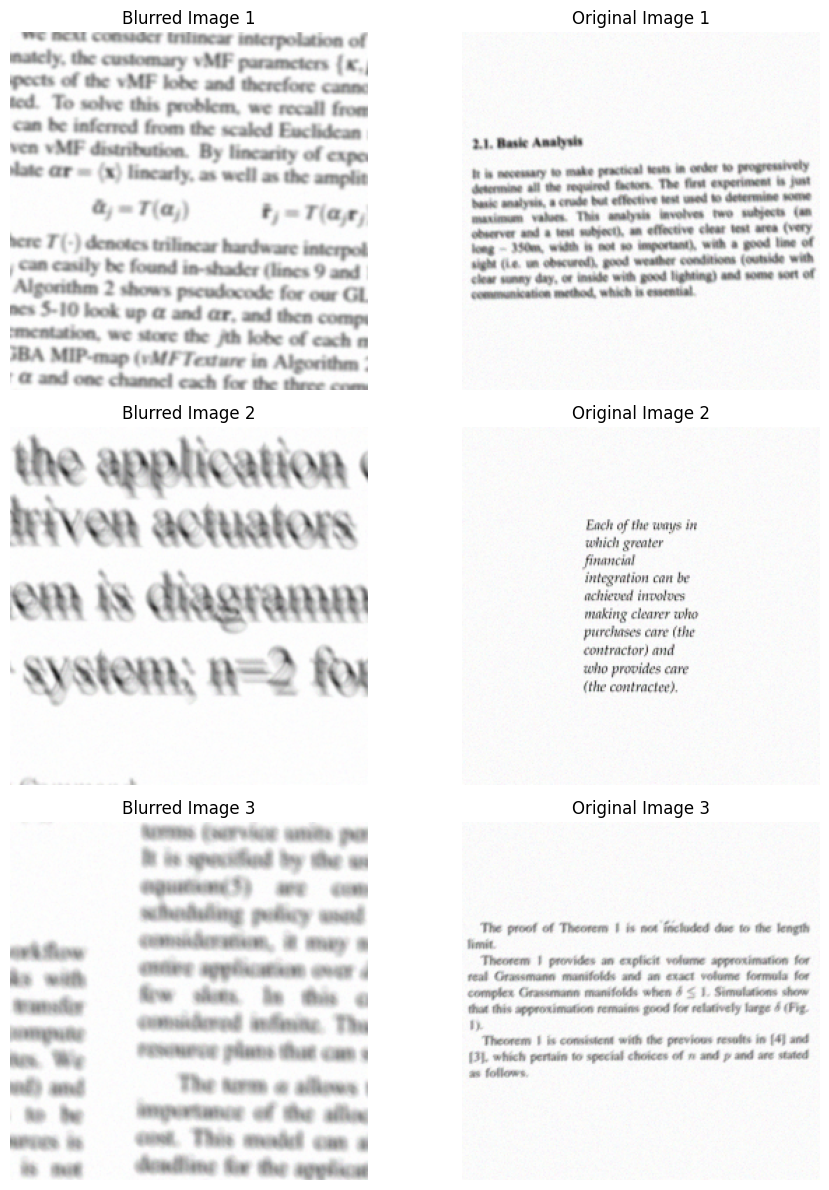

Sample visualization saved!


In [8]:
# Visualize sample pairs
if len(X) >= 3:
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))

    for i in range(3):
        axes[i, 0].imshow(X[i])
        axes[i, 0].set_title(f"Blurred Image {i+1}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(y[i])
        axes[i, 1].set_title(f"Original Image {i+1}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.savefig('/kaggle/working/sample_data.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Sample visualization saved!")
else:
    print(f"⚠️  Not enough images to visualize (need 3, have {len(X)})")

### Train/Validation Split

In [9]:
from sklearn.model_selection import train_test_split

# Check if we have enough data
if len(X) < 10:
    print(f"⚠️  Warning: Only {len(X)} images available. Consider using more data for better results.")
    if len(X) < 2:
        raise ValueError(f"Not enough data to split. Need at least 2 images, have {len(X)}")

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=CONFIG['VALIDATION_SPLIT'],
    random_state=42
)

print(f"✅ Dataset split completed:")
print(f"  Training samples: {len(X_train)}")
print(f"  Validation samples: {len(X_val)}")

✅ Dataset split completed:
  Training samples: 225
  Validation samples: 57


## 4. Model Architecture

Build the pretrained CNN-based autoencoder

In [11]:
def build_vgg16_autoencoder(input_shape, freeze_encoder=True):
    """
    Build VGG16-based autoencoder.
    """
    inputs = layers.Input(shape=input_shape, name='input_image')
    
    # Encoder: Pretrained VGG16
    vgg16_base = VGG16(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    
    if freeze_encoder:
        for layer in vgg16_base.layers:
            layer.trainable = False
    
    encoder_output = vgg16_base.output
    
    # Decoder: Upsampling path
    x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(encoder_output)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='VGG16_Autoencoder')
    return model


def build_resnet_autoencoder(input_shape, freeze_encoder=True):
    """
    Build ResNet50-based autoencoder.
    """
    inputs = layers.Input(shape=input_shape, name='input_image')
    
    # Encoder: Pretrained ResNet50
    resnet_base = ResNet50(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    
    if freeze_encoder:
        for layer in resnet_base.layers:
            layer.trainable = False
    
    encoder_output = resnet_base.output
    
    # Decoder: Upsampling path
    x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(encoder_output)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='ResNet50_Autoencoder')
    return model


# Build model
input_shape = (CONFIG['IMG_HEIGHT'], CONFIG['IMG_WIDTH'], CONFIG['IMG_CHANNELS'])

print(f"Building {CONFIG['MODEL_TYPE'].upper()} autoencoder...")

if CONFIG['MODEL_TYPE'] == 'vgg16':
    model = build_vgg16_autoencoder(input_shape, CONFIG['FREEZE_ENCODER'])
elif CONFIG['MODEL_TYPE'] == 'resnet50':
    model = build_resnet_autoencoder(input_shape, CONFIG['FREEZE_ENCODER'])
else:
    raise ValueError(f"Unknown model type: {CONFIG['MODEL_TYPE']}")

print(f"\nModel created successfully!")
print(f"Total parameters: {model.count_params():,}")

Building VGG16 autoencoder...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Model created successfully!
Total parameters: 18,646,531


### Model Summary

In [12]:
model.summary()

Model: "VGG16_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 18,646,531 (71.13 MB)

 Trainable params: 3,929,859 (14.99 MB)

 Non-trainable params: 14,716,672 (56.14 MB)

## 5. Compile Model

In [13]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss='mse',
    metrics=['mae']
)

print("Model compiled successfully!")

Model compiled successfully!


## 6. Callbacks Setup

In [14]:
# Define callbacks
model_name = f"{CONFIG['MODEL_TYPE']}_deblur_best.h5"
checkpoint_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], model_name)

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured:")
print("  - ModelCheckpoint (save best model)")
print("  - EarlyStopping (patience=10)")
print("  - ReduceLROnPlateau (patience=5)")

Callbacks configured:
  - ModelCheckpoint (save best model)
  - EarlyStopping (patience=10)
  - ReduceLROnPlateau (patience=5)


## 7. Train Model

In [15]:
# Train model
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=CONFIG['BATCH_SIZE'],
    epochs=CONFIG['EPOCHS'],
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)


STARTING TRAINING
Epoch 1/50


I0000 00:00:1762603812.776055     114 service.cc:148] XLA service 0x791ddc00e1c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762603812.777641     114 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762603813.622971     114 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.2647 - mae: 0.4311 

I0000 00:00:1762603825.879596     114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - loss: 0.1406 - mae: 0.2706

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 0.0188 - mae: 0.0708 - val_loss: 0.0227 - val_mae: 0.0595 - learning_rate: 0.0010
Epoch 14/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0288 - mae: 0.0767
Epoch 14: val_loss did not improve from 0.02273
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0292 - mae: 0.0776 - val_loss: 0.0244 - val_mae: 0.0645 - learning_rate: 0.0010
Epoch 15/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0249 - mae: 0.0751
Epoch 15: val_loss did not improve from 0.02273
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0253 - mae: 0.0755 - val_loss: 0.0256 - val_mae: 0.0547 - learning_rate: 0.0010
Epoch 16/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0212 - mae: 0.0722
Epoch 16: val_loss did not improve from 0.02273
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0219 - mae: 0.0733 - val_loss: 0.0294 - val_mae: 0.0645 - learning_rate: 0.0010
Epoch 17/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0242 - mae: 0.0735
Epoch 17: v

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - loss: 0.0240 - mae: 0.0734 - val_loss: 0.0210 - val_mae: 0.0701 - learning_rate: 0.0010
Epoch 18/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0233 - mae: 0.0773
Epoch 18: val_loss did not improve from 0.02105
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0241 - mae: 0.0778 - val_loss: 0.0263 - val_mae: 0.0549 - learning_rate: 0.0010
Epoch 19/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0323 - mae: 0.0822
Epoch 19: val_loss did not improve from 0.02105
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0317 - mae: 0.0817 - val_loss: 0.0310 - val_mae: 0.0831 - learning_rate: 0.0010
Epoch 20/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0207 - mae: 0.0682
Epoch 20: val_loss did not improve from 0.02105
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0209 - mae: 0.0684 - val_loss: 0.0226 - val_mae: 0.0572 - learning_rate: 0.0010
Epoch 21/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0223 - mae: 0.0709
Epoch 21: v

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.0222 - mae: 0.0682 - val_loss: 0.0202 - val_mae: 0.0543 - learning_rate: 5.0000e-04
Epoch 26/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0149 - mae: 0.0536
Epoch 26: val_loss did not improve from 0.02021
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0152 - mae: 0.0544 - val_loss: 0.0209 - val_mae: 0.0563 - learning_rate: 5.0000e-04
Epoch 27/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0188 - mae: 0.0646
Epoch 27: val_loss improved from 0.02021 to 0.01983, saving model to /kaggle/working/saved_models/vgg16_deblur_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.0193 - mae: 0.0650 - val_loss: 0.0198 - val_mae: 0.0569 - learning_rate: 5.0000e-04
Epoch 28/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0244 - mae: 0.0841
Epoch 28: val_loss did not improve from 0.01983
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0238 - mae: 0.0821 - val_loss: 0.0200 - val_mae: 0.0626 - learning_rate: 5.0000e-04
Epoch 29/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0156 - mae: 0.0583
Epoch 29: val_loss did not improve from 0.01983
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0157 - mae: 0.0583 - val_loss: 0.0222 - val_mae: 0.0554 - learning_rate: 5.0000e-04
Epoch 30/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0191 - mae: 0.0581
Epoch 30: val_loss improved from 0.01983 to 0.01944, saving model to /kaggle/working/saved_models/vgg16_deblur_best.h5


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0198 - mae: 0.0602 - val_loss: 0.0194 - val_mae: 0.0587 - learning_rate: 5.0000e-04
Epoch 31/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0150 - mae: 0.0590
Epoch 31: val_loss did not improve from 0.01944
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0151 - mae: 0.0592 - val_loss: 0.0205 - val_mae: 0.0626 - learning_rate: 5.0000e-04
Epoch 32/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0160 - mae: 0.0581
Epoch 32: val_loss did not improve from 0.01944
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0160 - mae: 0.0580 - val_loss: 0.0208 - val_mae: 0.0518 - learning_rate: 5.0000e-04
Epoch 33/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0145 - mae: 0.0539
Epoch 33: val_loss did not improve from 0.01944
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0146 - mae: 0.0539 - val_loss: 0.0199 - val_mae: 0.0545 - learning_rate: 5.0000e-04
Epoch 34/50
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0141 - mae: 0.

## 8. Training History Visualization

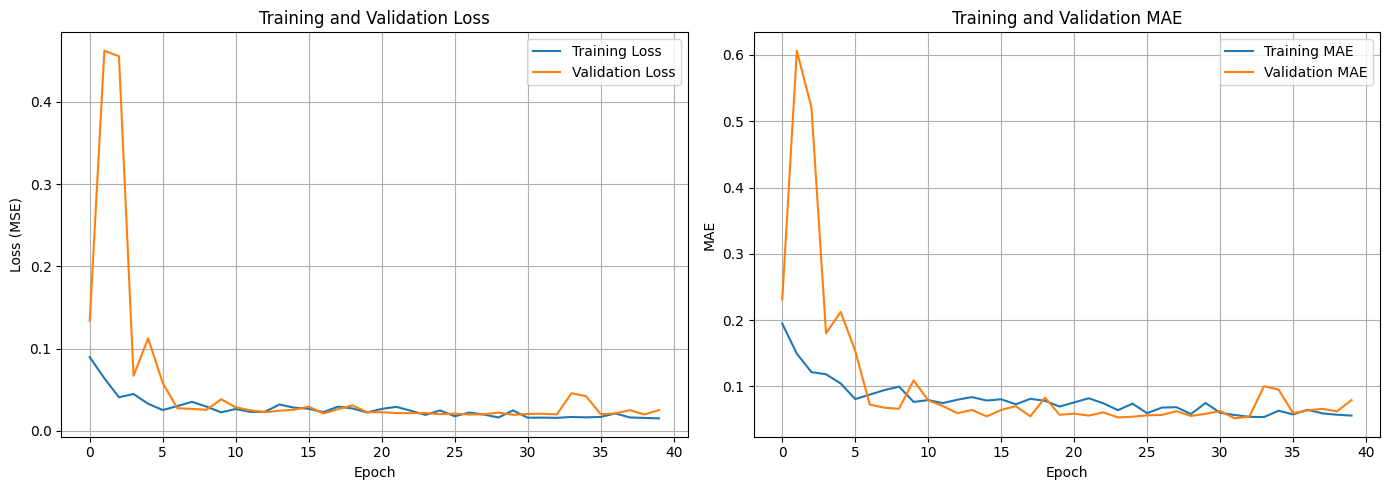

Training history plots saved!


In [16]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training and Validation MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history plots saved!")

## 9. Evaluate Model

In [18]:
# Load best model
print(f"Loading best model from: {checkpoint_path}")
from tensorflow.keras.losses import MeanSquaredError

model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={"mse": MeanSquaredError()}
)

# Make predictions on validation set
print("Making predictions on validation set...")
predictions = model.predict(X_val, batch_size=CONFIG['BATCH_SIZE'])

print(f"Predictions shape: {predictions.shape}")

Loading best model from: /kaggle/working/saved_models/vgg16_deblur_best.h5


Making predictions on validation set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 431ms/step
Predictions shape: (57, 256, 256, 3)


### Calculate PSNR and SSIM

In [19]:
# Calculate metrics
psnr_values = []
ssim_values = []

print("Calculating PSNR and SSIM metrics...")

for i in range(len(y_val)):
    # PSNR
    psnr_val = psnr(y_val[i], predictions[i], data_range=1.0)
    psnr_values.append(psnr_val)
    
    # SSIM
    ssim_val = ssim(y_val[i], predictions[i], data_range=1.0, channel_axis=2)
    ssim_values.append(ssim_val)

# Display results
print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)
print(f"PSNR (Peak Signal-to-Noise Ratio):")
print(f"  Mean: {np.mean(psnr_values):.2f} dB")
print(f"  Std:  {np.std(psnr_values):.2f} dB")
print(f"\nSSIM (Structural Similarity Index):")
print(f"  Mean: {np.mean(ssim_values):.4f}")
print(f"  Std:  {np.std(ssim_values):.4f}")
print("="*60)

Calculating PSNR and SSIM metrics...

EVALUATION METRICS
PSNR (Peak Signal-to-Noise Ratio):
  Mean: 18.48 dB
  Std:  3.22 dB

SSIM (Structural Similarity Index):
  Mean: 0.6631
  Std:  0.0955


### Visualize Results

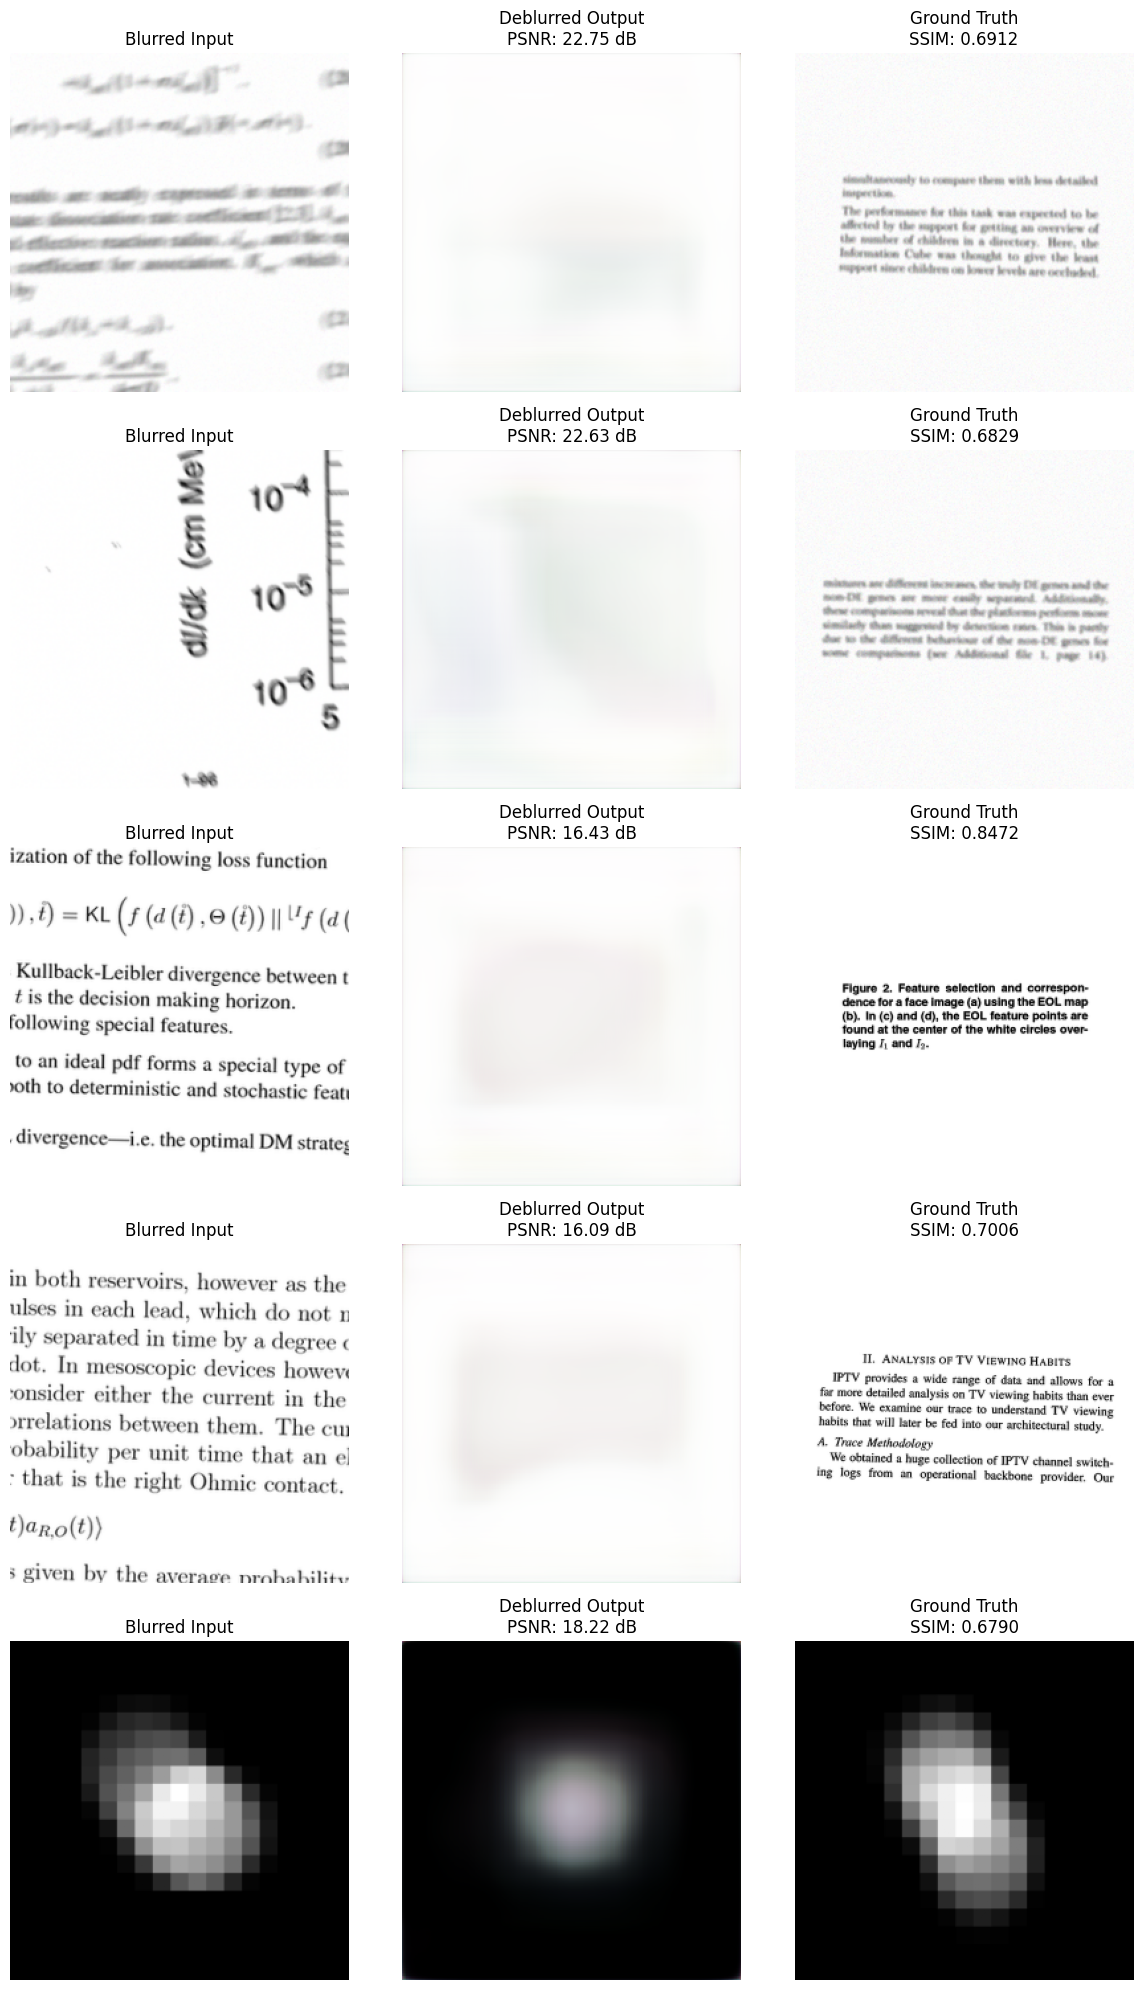

Results visualization saved!


In [20]:
# Visualize predictions
num_samples = min(5, len(X_val))
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for i in range(num_samples):
    # Blurred input
    axes[i, 0].imshow(X_val[i])
    axes[i, 0].set_title("Blurred Input")
    axes[i, 0].axis('off')
    
    # Deblurred output
    axes[i, 1].imshow(predictions[i])
    axes[i, 1].set_title(f"Deblurred Output\nPSNR: {psnr_values[i]:.2f} dB")
    axes[i, 1].axis('off')
    
    # Ground truth
    axes[i, 2].imshow(y_val[i])
    axes[i, 2].set_title(f"Ground Truth\nSSIM: {ssim_values[i]:.4f}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/deblur_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Results visualization saved!")

## 10. Save Final Model

In [23]:
import os

# Save final model in HDF5 format
final_model_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], f"{CONFIG['MODEL_TYPE']}_deblur_final.h5")
model.save(final_model_path)   # HDF5 format
print(f"\nFinal model saved to: {final_model_path}")
print(f"Best model saved to: {checkpoint_path}")

# Save model in Keras v3 format (optional, recommended for future compatibility)
keras_model_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], f"{CONFIG['MODEL_TYPE']}_deblur_final.keras")
model.save(keras_model_path)
print(f"Keras format saved to: {keras_model_path}")

# Export model in TensorFlow SavedModel format (for deployment)
saved_model_dir = os.path.join(CONFIG['MODEL_SAVE_PATH'], f"{CONFIG['MODEL_TYPE']}_savedmodel")
model.export(saved_model_dir)   # <-- use export, not save
print(f"SavedModel format exported to: {saved_model_dir}")



Final model saved to: /kaggle/working/saved_models/vgg16_deblur_final.h5
Best model saved to: /kaggle/working/saved_models/vgg16_deblur_best.h5
Keras format saved to: /kaggle/working/saved_models/vgg16_deblur_final.keras
INFO:tensorflow:Assets written to: /kaggle/working/saved_models/vgg16_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/saved_models/vgg16_savedmodel/assets


Saved artifact at '/kaggle/working/saved_models/vgg16_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None)
Captures:
  133171729151184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729151760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729152336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729152912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729152144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729153680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729153104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729153872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729150608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133171729153488: TensorSpec(shape=(), dtype=tf

## 11. Export Metrics Summary

In [24]:
# Save metrics to file
import json

metrics_summary = {
    'model_type': CONFIG['MODEL_TYPE'],
    'total_epochs': len(history.history['loss']),
    'final_train_loss': float(history.history['loss'][-1]),
    'final_val_loss': float(history.history['val_loss'][-1]),
    'psnr_mean': float(np.mean(psnr_values)),
    'psnr_std': float(np.std(psnr_values)),
    'ssim_mean': float(np.mean(ssim_values)),
    'ssim_std': float(np.std(ssim_values)),
    'num_train_samples': len(X_train),
    'num_val_samples': len(X_val)
}

metrics_path = os.path.join(CONFIG['MODEL_SAVE_PATH'], 'metrics_summary.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=4)

print(f"Metrics summary saved to: {metrics_path}")
print("\nTraining complete! All outputs saved.")

Metrics summary saved to: /kaggle/working/saved_models/metrics_summary.json

Training complete! All outputs saved.


## 12. Test on New Image (Optional)

Use this cell to test the model on a custom blurred image

In [25]:
# Function to deblur a single image
def deblur_image(model, image_path, img_size):
    """
    Deblur a single image using the trained model.
    """
    # Load and preprocess
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    
    # Add batch dimension
    img_batch = np.expand_dims(img, axis=0)
    
    # Predict
    deblurred = model.predict(img_batch, verbose=0)
    
    return img, deblurred[0]

# Example usage (uncomment to use with your own image)
# test_image_path = '/kaggle/input/your-test-image.jpg'
# blurred, deblurred = deblur_image(model, test_image_path, img_size)
# 
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# axes[0].imshow(blurred)
# axes[0].set_title('Blurred Input')
# axes[0].axis('off')
# axes[1].imshow(deblurred)
# axes[1].set_title('Deblurred Output')
# axes[1].axis('off')
# plt.show()

print("Test function ready! Upload an image and uncomment the code above to test.")

Test function ready! Upload an image and uncomment the code above to test.
